# 🗂️ Manage Data — Join CSV Files

This notebook **concatenates two SAP log CSV files** into a single `output/logs.csv`  
that the FastAPI container reads on startup.

### Steps
1. Load both source CSVs and preview them  
2. Concatenate (vertical stack — same 44-column schema)  
3. Deduplicate on `_id` (UUID)  
4. Sort by `@timestamp`  
5. Summary of the combined dataset  
6. Save to `output/logs.csv`  

In [24]:
import warnings
warnings.filterwarnings('ignore')

import os
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Libraries loaded ✓')

Libraries loaded ✓


## 1 · Define Paths

In [37]:
# ── Paths (relative to repo root) ──────────────────────────────────────────
OUTPUT_DIR = '../output'

FILE_A = os.path.join(OUTPUT_DIR, 'new_logs_18_23.csv')   # first batch
FILE_B = os.path.join(OUTPUT_DIR, 'new_logs_23_25.csv')   # second batch
FILE_C = os.path.join(OUTPUT_DIR, 'new_logs_25_30.csv') # 3th

OUT    = os.path.join(OUTPUT_DIR, 'delete_logs.csv')           # combined → API reads this

for f in [FILE_A, FILE_B, FILE_C]:
    size_mb = os.path.getsize(f) / 1_048_576
    print(f'  {os.path.basename(f):30s}  {size_mb:7.1f} MB')

print(f'\nOutput → {OUT}')

  new_logs_18_23.csv                858.4 MB
  new_logs_23_25.csv                281.4 MB
  new_logs_25_30.csv                858.4 MB

Output → ../output/delete_logs.csv


## 2 · Load & Preview Each File

In [38]:
print('Loading file A …')
df_a = pd.read_csv(FILE_A, dtype=str, keep_default_na=False, low_memory=False)
print(f'  File A : {len(df_a):>10,} rows  ×  {df_a.shape[1]} columns')

print('Loading file B …')
df_b = pd.read_csv(FILE_B, dtype=str, keep_default_na=False, low_memory=False)
print(f'  File B : {len(df_b):>10,} rows  ×  {df_b.shape[1]} columns')

print('Loading file C …')
df_c = pd.read_csv(FILE_C, dtype=str, keep_default_na=False, low_memory=False)
print(f'  File C : {len(df_c):>10,} rows  ×  {df_c.shape[1]} columns')

print(f'\nTotal rows before dedup : {len(df_a) + len(df_b) + len(df_c):,}')

Loading file A …
  File A :  1,589,135 rows  ×  44 columns
Loading file B …
  File B :    519,103 rows  ×  44 columns
Loading file C …
  File C :  1,589,135 rows  ×  44 columns

Total rows before dedup : 3,697,373


In [41]:
# ── Quick sanity check: same columns? ──────────────────────────────────────
cols_a = set(df_a.columns)
cols_b = set(df_b.columns)
cols_c = set(df_c.columns)

only_in_a = cols_a - cols_b
only_in_b = cols_b - cols_a
only_in_c = cols_c - cols_a          # cols C has that A doesn't
missing_in_c = cols_a - cols_c       # cols A has that C doesn't

if not only_in_a and not only_in_b and not only_in_c and not missing_in_c:
    print('✅  All three files share the same columns — safe to concatenate.')
else:
    if only_in_a:
        print(f'⚠️  Columns only in A : {only_in_a}')
    if only_in_b:
        print(f'⚠️  Columns only in B : {only_in_b}')
    if only_in_c:
        print(f'⚠️  Columns only in C : {only_in_c}')
    if missing_in_c:
        print(f'⚠️  Columns missing in C (present in A) : {missing_in_c}')
    print('   Missing columns will be filled with empty strings after concat.')


✅  All three files share the same columns — safe to concatenate.


In [42]:
# ── Date ranges per file ────────────────────────────────────────────────────
for label, df_tmp in [('File A', df_a), ('File B', df_b), ('File C', df_c)]:
    ts = pd.to_datetime(df_tmp['@timestamp'], utc=True, errors='coerce')
    print(f'{label}  →  {ts.min()}  …  {ts.max()}')

File A  →  2026-04-18 00:00:00+00:00  …  2026-04-23 00:00:00+00:00
File B  →  2026-04-23 00:00:00+00:00  …  2026-04-25 00:00:00+00:00
File C  →  2026-04-25 00:00:00+00:00  …  2026-04-30 00:00:00+00:00


## 3 · Concatenate

In [43]:
# Vertical stack — same schema, just more rows
df = pd.concat([df_a, df_b, df_c], ignore_index=True)

print(f'After concat  : {len(df):,} rows')

After concat  : 3,697,373 rows


## 4 · Deduplicate on `_id`

In [44]:
before = len(df)
df = df.drop_duplicates(subset='_id', keep='first')
dupes_removed = before - len(df)

print(f'Duplicates removed : {dupes_removed:,}')
print(f'After dedup        : {len(df):,} rows')

Duplicates removed : 0
After dedup        : 3,697,373 rows


## 5 · Sort by `@timestamp`

In [45]:
df['_ts_sort'] = pd.to_datetime(df['@timestamp'], utc=True, errors='coerce')
df = df.sort_values('_ts_sort').drop(columns='_ts_sort').reset_index(drop=True)

ts = pd.to_datetime(df['@timestamp'], utc=True, errors='coerce')
print(f'Date range : {ts.min()}  →  {ts.max()}')
print(f'Final shape: {df.shape[0]:,} rows × {df.shape[1]} columns')

Date range : 2026-04-18 00:00:00+00:00  →  2026-04-30 00:00:00+00:00
Final shape: 3,697,373 rows × 44 columns


## 6 · Summary of Combined Dataset

In [46]:
log_cat = df['sap_function_log_type'].apply(
    lambda x: 'LLM' if str(x).startswith('LLM') else 'System'
)

print('=== Combined Dataset Summary ===')
print(f'  Total rows      : {len(df):,}')
print(f'  System log rows : {(log_cat == "System").sum():,}  '
      f'({(log_cat == "System").mean()*100:.1f}%)')
print(f'  LLM log rows    : {(log_cat == "LLM").sum():,}  '
      f'({(log_cat == "LLM").mean()*100:.1f}%)')
print(f'  Unique _id      : {df["_id"].nunique():,}')
print(f'  Columns         : {df.shape[1]}')

print('\n=== Log Type Breakdown ===')
print(df['sap_function_log_type'].value_counts().to_string())

print('\n=== Source Files ===')
print(f'  {os.path.basename(FILE_A)}')
print(f'  {os.path.basename(FILE_B)}')
print(f'  {os.path.basename(FILE_C)}')

=== Combined Dataset Summary ===
  Total rows      : 3,697,373
  System log rows : 2,233,015  (60.4%)
  LLM log rows    : 1,464,358  (39.6%)
  Unique _id      : 3,697,373
  Columns         : 44

=== Log Type Breakdown ===
sap_function_log_type
LLM_REQUEST    1025921
INFO            830258
WARNING         411663
ERROR           310659
LLM_ERROR       291855
AUDIT           206684
PERF            205543
DEBUG           205513
LLM_TIMEOUT     146582
SECURITY         62695

=== Source Files ===
  new_logs_18_23.csv
  new_logs_23_25.csv
  new_logs_25_30.csv


## 6.5 · Timeseries Visualization

Two views of the **full date range** in the combined dataset:
- **Events per day** — daily event count
- **Events per hour** — hourly event count

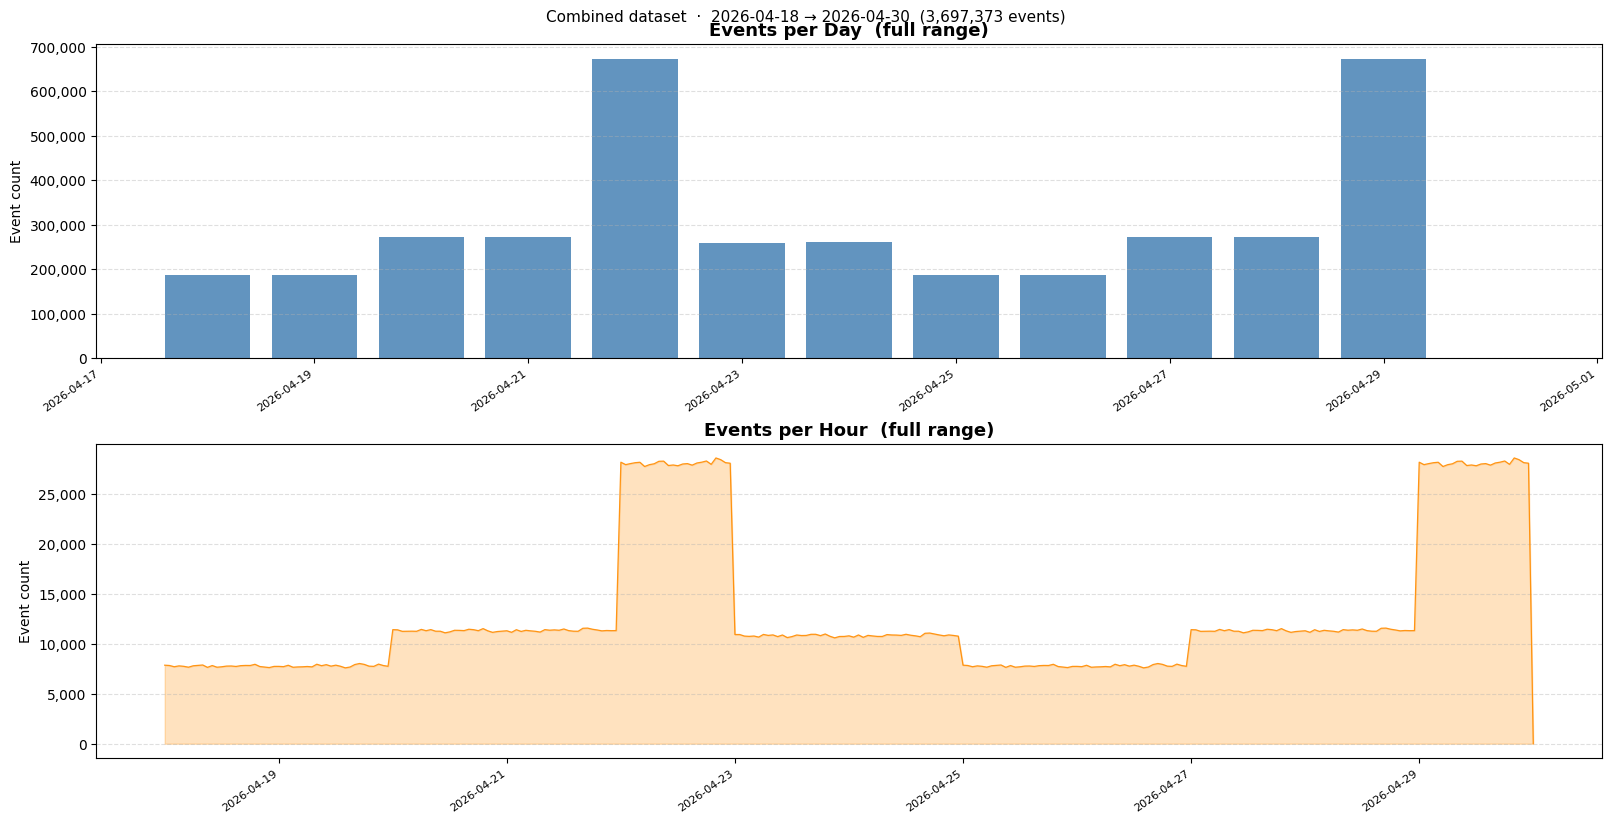

Daily  buckets : 13
Hourly buckets : 289


In [47]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Parse timestamps ────────────────────────────────────────────────────────
ts = pd.to_datetime(df['@timestamp'], utc=True, errors='coerce')

# ── 1 · Events per day ──────────────────────────────────────────────────────
daily = ts.dt.floor('D').value_counts().sort_index()

# ── 2 · Events per hour ─────────────────────────────────────────────────────
hourly = ts.dt.floor('h').value_counts().sort_index()

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), constrained_layout=True)

# — Daily —
ax = axes[0]
ax.bar(daily.index, daily.values, width=0.8, color='steelblue', alpha=0.85)
ax.set_title('Events per Day  (full range)', fontsize=13, fontweight='bold')
ax.set_ylabel('Event count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# — Hourly —
ax = axes[1]
ax.plot(hourly.index, hourly.values, linewidth=0.9, color='darkorange', alpha=0.9)
ax.fill_between(hourly.index, hourly.values, alpha=0.25, color='darkorange')
ax.set_title('Events per Hour  (full range)', fontsize=13, fontweight='bold')
ax.set_ylabel('Event count')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.suptitle(
    f'Combined dataset  ·  {ts.min().date()} → {ts.max().date()}  '
    f'({len(df):,} events)',
    fontsize=11, y=1.01
)
plt.show()
print(f'Daily  buckets : {len(daily):,}')
print(f'Hourly buckets : {len(hourly):,}')

## 7 · Save to `output/logs.csv`

> This is the file the FastAPI container reads on startup (`CSV_PATH = output/logs.csv`).  
> After saving, restart the container to pick up the new data.

In [48]:
OUT    = os.path.join(OUTPUT_DIR, 'new_logs_18_30.csv')           # combined → API reads this


In [49]:
df.to_csv(OUT, index=False)

size_mb = os.path.getsize(OUT) / 1_048_576
print(f'✅  Saved → {OUT}')
print(f'   {len(df):,} rows  |  {size_mb:.1f} MB')
print()
print('Next step: restart the container to reload the data.')
print('  podman-compose -f ../podman-compose.yml restart api')

✅  Saved → ../output/new_logs_18_30.csv
   3,697,373 rows  |  1997.8 MB

Next step: restart the container to reload the data.
  podman-compose -f ../podman-compose.yml restart api
